In [2]:
#!/usr/bin/env python3
"""
==============================================================================
HAOR FLOOD — HYDROLOGICAL YEAR ANALYSIS v3  (haor_flood_hydroyear.ipynb)
==============================================================================
Updates haor_flood_multiyear.ipynb. Reads the exports from
haor_export_hydroyear.py, which supersedes haor_export_multiyear.py.

  THREE METHOD CHANGES IN v3 (from the 7 July supervisor meeting):
  1. HYDROLOGICAL YEAR. The season runs 1 Apr of year Y to 31 Mar of year Y+1
     (~455 days) instead of stopping at 31 Dec, so the recession completes
     inside the data. Day numbers are days since 1 Jan of the analysis year,
     so January of Y+1 reads ~370 rather than wrapping back to ~15.
  2. PERSISTENCE FILLING. A pixel the satellite did not see inherits its last
     true observation, but only across gaps up to MAX_GAP_DAYS (one full S1
     revisit). Filled values are never a source for later filling, so gaps
     cannot chain. The connectivity coverage guard still uses the RAW observed
     fraction, so filling completes maps within good dates and never lets a
     poorly observed date through.
  3. ONE POOLED BASELINE AND ONE PERMANENT WATER MASK. The Z-score reference is
     a single mean and standard deviation pooled over the dry seasons (Jan to
     Mar) of all seven years. That same pooled mean defines permanent water,
     unioned with JRC occurrence above 75%, applied identically to every year.
     Caveat: pooling captures between-year as well as within-year variability,
     so the standard deviation inflates and detection at a fixed z = -2.5 is
     slightly less sensitive. The export script prints the inflation factor.

  CARRIED OVER: wet-season merge metrics, multi-year grids, Kendall's W, the
  FABDEM rim and sill mechanism test, and the SWOT validation.

  NOT CHANGED, deliberately, so that what moves can be attributed: permanent
  water is still excluded from the connectivity water definition. Treating
  permanent channels as connecting water is a separate question for later.

RUN ORDER: top to bottom.
==============================================================================
"""
import os, re, glob, datetime
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import geometry_mask
from rasterio.mask import mask as rmask
from rasterio.warp import reproject, Resampling
from shapely.geometry import mapping
from scipy import ndimage
from scipy.stats import spearmanr, chi2 as chi2_dist
print("\u2713 imports ok")


✓ imports ok


In [28]:
# %%
# ============================ PATHS & CONFIG (hydro year) ============================
BASE       = "/work/a06/wasif/haor_flood_analysis_hydroyear"     # NEW folder from haor_export_hydroyear.py
HAORS_SHP  = "/work/a06/wasif/haor_flood_analysis/digitization/haors_manual.shp"
FABDEM_TIF = "/work/a06/wasif/haor_flood_analysis/fabdem_elevation.tif"
JRC_CANDIDATES = [
    "/work/a06/wasif/haor_flood_analysis/haor_digitization_tanguar/tanguar_jrc_occurrence.tif",
    "/work/a06/wasif/haor_flood_analysis/jrc_water_occurrence.tif",
    os.path.join(BASE, "tanguar_jrc_occurrence.tif"),
]
JRC_TIF = next((p for p in JRC_CANDIDATES if os.path.exists(p)), None)
assert JRC_TIF, "No JRC occurrence raster found - check JRC_CANDIDATES paths."

# SWOT: the extraction CSV already exists in the OLD folder and does not need re-running.
SWOT_CSV = "/work/a06/wasif/haor_flood_analysis_multiyear/analysis/swot_perhaor_wse.csv"
CLUSTER_BBOX = [90.85, 24.85, 91.50, 25.25]   # W,S,E,N

ANALYSIS_ROOT = os.path.join(BASE, "analysis")
os.makedirs(ANALYSIS_ROOT, exist_ok=True)

# ---- analysis knobs ----
LEVEL             = 0.50   # onset / recession at 50% of each haor's own maximum
MIN_PX, BRIDGE    = 10, 1  # speckle filter, one-pixel bridge guard
MIN_OBSERVED_FRAC = 0.50   # coverage guard, applied to RAW observed fraction
BUFFER_PX         = 8      # ~800 m study-area ring around the haors
CENTRAL_HAOR      = "GMA"

# ---- NEW in v3: persistence filling ----
FILL_GAPS    = True
MAX_GAP_DAYS = 12.0        # one full Sentinel-1 revisit; older states are not carried

# ---- NEW in v3: permanent water from the pooled dry-season baseline ----
WATER_DB                  = -13.0  # pooled dry-season VV below this = open water
PERMANENT_WATER_THRESHOLD = 75     # JRC occurrence percent

YEARS = sorted(int(re.search(r"(\d{4})", os.path.basename(f)).group(1))
               for f in glob.glob(os.path.join(BASE, "flood_stack_cluster_*.tif")))
print("BASE:", BASE)
print("JRC :", JRC_TIF)
print("years found:", YEARS)
assert YEARS, "no flood_stack_cluster_<year>.tif found in BASE - check the download"

os.environ["SHAPE_RESTORE_SHX"] = "YES"
haors = gpd.read_file(HAORS_SHP)
haors = haors[haors["haor_id"] != "DUMMY"].copy()
HAOR_IDS = haors["haor_id"].tolist()
print("haors:", HAOR_IDS)


BASE: /work/a06/wasif/haor_flood_analysis_hydroyear
JRC : /work/a06/wasif/haor_flood_analysis/haor_digitization_tanguar/tanguar_jrc_occurrence.tif
years found: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
haors: ['MTN', 'SHN', 'HLR', 'TGR', 'GMA']


In [29]:
# %%
# ============================ HELPERS (hydro year) ============================
def _dayidx(desc, base_year):
    """Days since 1 Jan of the ANALYSIS year. January of the following year
    becomes ~370, not ~15, so the season stays in chronological order. These are
    the same units GEE writes into first_wet_date and last_wet_date."""
    m = re.search(r"(20\d{2})(\d{2})(\d{2})", desc or "")
    if not m:
        return np.nan
    y, mo, d = map(int, m.groups())
    return float((datetime.date(y, mo, d) - datetime.date(base_year, 1, 1)).days)

def read_on_grid(path, shape, transform, crs, how=Resampling.nearest):
    """Read a raster onto the stack's grid, reprojecting only if it differs."""
    with rasterio.open(path) as s:
        if (s.height, s.width) == shape and s.crs == crs:
            a = s.read(1).astype("float32")
            if s.nodata is not None:
                a[a == s.nodata] = np.nan
            return a
        dst = np.full(shape, np.nan, "float32")
        reproject(rasterio.band(s, 1), dst, src_transform=s.transform, src_crs=s.crs,
                  dst_transform=transform, dst_crs=crs, resampling=how)
        return dst

def persistence_fill(bands, days, max_gap):
    """Carry each pixel's LAST TRUE OBSERVATION forward across gaps up to
    max_gap days. Filled values are never used as a source for later filling,
    so gaps cannot chain. Returns (filled_bands, n_filled_pixel_dates)."""
    filled = [b.copy() for b in bands]
    last_v = np.full(bands[0].shape, np.nan, "float32")
    last_d = np.full(bands[0].shape, -9e9, "float32")
    n_fill = 0
    for i, b in enumerate(bands):
        obs = np.isfinite(b)
        can = (~obs) & np.isfinite(last_v) & ((days[i] - last_d) <= max_gap)
        filled[i][can] = last_v[can]
        n_fill += int(can.sum())
        last_v[obs] = b[obs]
        last_d[obs] = days[i]
    return filled, n_fill
print("\u2713 helpers defined")


✓ helpers defined


grid: (447, 725) EPSG:4326
pooled dry-season mean range: -23.7 to 2.5 dB
  S1 only    : 10,840 pixels
  JRC only   : 5,729 pixels
  both agree : 9,617 pixels
  FINAL mask : 26,186 pixels (8.08% of grid)

permanent pixels removed per haor:
  MTN: 1,466 of 6,004 (24.4%)
  SHN: 1,548 of 9,127 (17.0%)
  HLR: 1,404 of 8,897 (15.8%)
  TGR: 4,199 of 9,698 (43.3%)
  GMA: 1,240 of 7,353 (16.9%)


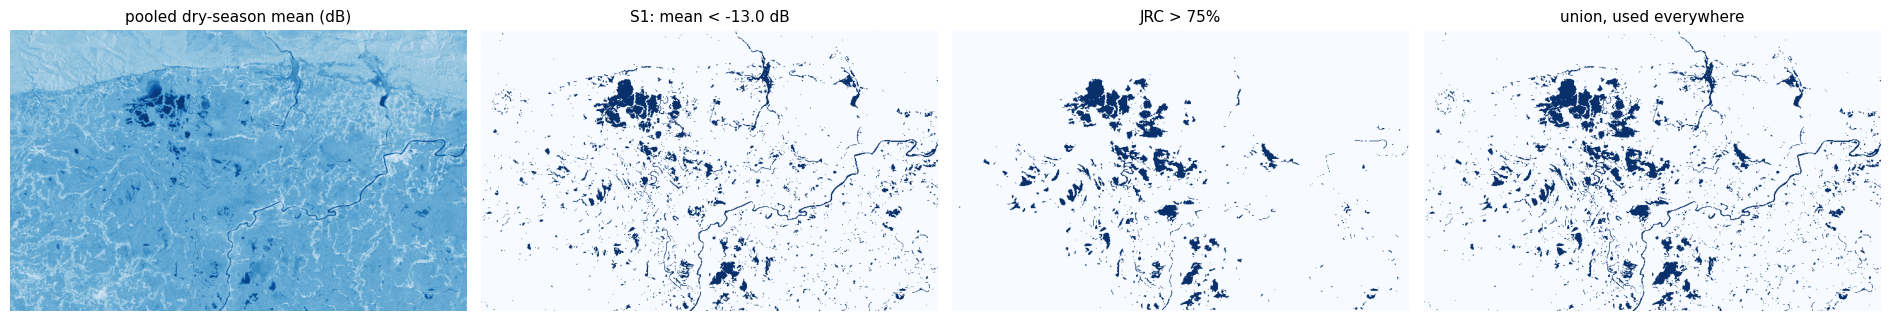

In [30]:
# %%
# ============ PERMANENT WATER MASK (from the pooled dry-season baseline) ============
# The pooled baseline mean is average dry-season backscatter over all seven
# Jan-Mar periods. A pixel dark in that average is open water in every dry
# season, so it is permanent. Unioned with JRC: a missed permanent pixel
# corrupts timing, while an extra masked pixel only costs a little area.
_ref = os.path.join(BASE, f"flood_stack_cluster_{YEARS[0]}.tif")
with rasterio.open(_ref) as _s:
    GRID_SHAPE, GRID_TRANSFORM, GRID_CRS = (_s.height, _s.width), _s.transform, _s.crs
print("grid:", GRID_SHAPE, GRID_CRS)

mean_path = os.path.join(BASE, "baseline_mean_pooled.tif")
assert os.path.exists(mean_path), f"missing {mean_path} - did the export finish?"
mean_pooled = read_on_grid(mean_path, GRID_SHAPE, GRID_TRANSFORM, GRID_CRS, Resampling.bilinear)

perm_s1   = np.isfinite(mean_pooled) & (mean_pooled < WATER_DB)
jrc_g     = read_on_grid(JRC_TIF, GRID_SHAPE, GRID_TRANSFORM, GRID_CRS, Resampling.bilinear)
perm_jrc  = np.isfinite(jrc_g) & (jrc_g > PERMANENT_WATER_THRESHOLD)
PERM_MASK = perm_s1 | perm_jrc

print(f"pooled dry-season mean range: {np.nanmin(mean_pooled):.1f} to {np.nanmax(mean_pooled):.1f} dB")
print(f"  S1 only    : {int((perm_s1 & ~perm_jrc).sum()):,} pixels")
print(f"  JRC only   : {int((perm_jrc & ~perm_s1).sum()):,} pixels")
print(f"  both agree : {int((perm_s1 &  perm_jrc).sum()):,} pixels")
print(f"  FINAL mask : {int(PERM_MASK.sum()):,} pixels "
      f"({100*PERM_MASK.sum()/PERM_MASK.size:.2f}% of grid)")

with rasterio.open(_ref) as _s:
    _hv = haors.to_crs(_s.crs)
    HAOR_MASKS = {h.haor_id: geometry_mask([h.geometry], GRID_SHAPE, GRID_TRANSFORM, invert=True)
                  for _, h in _hv.iterrows()}
print("\npermanent pixels removed per haor:")
for hid, m in HAOR_MASKS.items():
    tot = int(m.sum()); perm = int((m & PERM_MASK).sum())
    print(f"  {hid}: {perm:,} of {tot:,} ({100*perm/max(tot,1):.1f}%)")

fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
for a_, img, t in zip(ax, [mean_pooled, perm_s1, perm_jrc, PERM_MASK],
        ["pooled dry-season mean (dB)", f"S1: mean < {WATER_DB} dB",
         f"JRC > {PERMANENT_WATER_THRESHOLD}%", "union, used everywhere"]):
    a_.imshow(img, cmap="Blues_r" if "dB)" in t else "Blues")
    a_.set_title(t, fontsize=11); a_.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "permanent_water_mask.png"), dpi=150)
plt.show()


In [6]:
# %%
# ============ PER-YEAR ANALYSIS (hydro year, persistence filled, shared mask) ============
def analyze_year(year, perm_mask, fill=FILL_GAPS):
    stack_tif = os.path.join(BASE, f"flood_stack_cluster_{year}.tif")
    fwd_tif   = os.path.join(BASE, f"first_wet_date_{year}.tif")
    lwd_tif   = os.path.join(BASE, f"last_wet_date_{year}.tif")
    for p in (stack_tif, fwd_tif, lwd_tif):
        if not os.path.exists(p):
            print(f"  [{year}] missing {os.path.basename(p)}, skipped"); return None
    outdir = os.path.join(ANALYSIS_ROOT, str(year)); os.makedirs(outdir, exist_ok=True)

    with rasterio.open(stack_tif) as src:
        nod = src.nodata
        shape, transform, crs = (src.height, src.width), src.transform, src.crs
        days = np.array([_dayidx(d, year) for d in src.descriptions], float)
        bands = []
        for i in range(src.count):
            b = src.read(i + 1).astype("float32")
            if nod is not None:
                b[b == nod] = np.nan
            bands.append(b)
        hv = haors.to_crs(crs)
        masks = {h.haor_id: geometry_mask([h.geometry], shape, transform, invert=True)
                 for _, h in hv.iterrows()}

    # guards against the two silent-failure modes
    if shape != perm_mask.shape:
        raise ValueError(f"{year}: stack grid {shape} != permanent mask {perm_mask.shape}")
    if (~np.isfinite(days)).any():
        raise ValueError(f"{year}: {int((~np.isfinite(days)).sum())} band names did not parse to a date")

    order = np.argsort(days)
    days  = days[order]; bands = [bands[i] for i in order]

    cluster_pixels = np.zeros(shape, bool)
    for m in masks.values():
        cluster_pixels |= m
    n_cluster = int(cluster_pixels.sum())

    # RAW coverage per date, computed BEFORE filling: this is what guards connectivity
    obs_raw = np.array([float((np.isfinite(b) & cluster_pixels).sum()) / n_cluster for b in bands])

    n_fill = 0
    if fill:
        bands, n_fill = persistence_fill(bands, days, MAX_GAP_DAYS)
    obs_eff = np.array([float((np.isfinite(b) & cluster_pixels).sum()) / n_cluster for b in bands])

    # ---- hydrographs: analysis pixels exclude permanent water ----
    keep = ~perm_mask
    curves = {}
    for hid, m in masks.items():
        sel = m & keep
        fr = []
        for b in bands:
            sub = b[sel]; ok = np.isfinite(sub); n = int(ok.sum())
            fr.append(int((sub[ok] == 1).sum()) / n if n else np.nan)
        curves[hid] = np.array(fr, float)
    pd.DataFrame({"doy": days, "obs_raw": obs_raw, "obs_eff": obs_eff, **curves}).to_csv(
        os.path.join(outdir, f"haor_hydrograph_curves_{year}.csv"), index=False)

    trows = []
    for hid, f in curves.items():
        ok = np.isfinite(f)
        d, ff = days[ok], f[ok]
        if ff.size == 0 or not np.isfinite(np.nanmax(ff)):
            continue
        fmax = np.nanmax(ff); above = d[ff >= LEVEL * fmax]
        trows.append(dict(haor_id=hid,
            onset_hydro=float(above.min()) if above.size else np.nan,
            peak_hydro=float(d[np.argmax(ff)]),
            recession_hydro=float(above.max()) if above.size else np.nan,
            max_fraction=round(float(fmax), 3)))
    timing = pd.DataFrame(trows)
    timing.to_csv(os.path.join(outdir, f"haor_hydrograph_timing_{year}.csv"), index=False)

    # ---- connectivity: guard on RAW coverage ----
    study = ndimage.binary_dilation(cluster_pixels, iterations=BUFFER_PX)
    crecs, cmat = [], []
    for i, b in enumerate(bands):
        if obs_raw[i] < MIN_OBSERVED_FRAC:
            crecs.append(dict(doy=days[i], n_components=-1, largest_frac=-1, total_wet=-1,
                              obs_raw=round(obs_raw[i], 3), obs_eff=round(obs_eff[i], 3),
                              all_connected=False))
            cmat.append(dict(doy=days[i], **{h: -1 for h in masks}))
            continue
        water = np.isfinite(b) & (b == 1) & study
        if BRIDGE:
            water = ndimage.binary_opening(water, iterations=BRIDGE)
        lab, n = ndimage.label(water)
        if n:
            sz = ndimage.sum(np.ones_like(lab), lab, index=np.arange(1, n + 1))
            water &= np.isin(lab, np.where(sz >= MIN_PX)[0] + 1)
            lab, n = ndimage.label(water)
        total = int(water.sum())
        largest = float(ndimage.sum(np.ones_like(lab), lab,
                        index=np.arange(1, n + 1)).max() / total) if (n and total) else 0.0
        comp = {}
        for hid, m in masks.items():
            v = lab[m & (lab > 0)]
            comp[hid] = int(np.bincount(v).argmax()) if v.size else 0
        nz = [x for x in comp.values() if x > 0]
        crecs.append(dict(doy=days[i], n_components=int(n), largest_frac=round(largest, 3),
                          total_wet=total, obs_raw=round(obs_raw[i], 3),
                          obs_eff=round(obs_eff[i], 3),
                          all_connected=(len(nz) == len(masks) and len(set(nz)) == 1)))
        cmat.append(dict(doy=days[i], **comp))
    conn_df   = pd.DataFrame(crecs).sort_values("doy")
    matrix_df = pd.DataFrame(cmat).sort_values("doy")
    conn_df.to_csv(os.path.join(outdir, f"connectivity_curve_{year}.csv"), index=False)
    matrix_df.to_csv(os.path.join(outdir, f"haor_connection_matrix_{year}.csv"), index=False)

    # ---- per-pixel onset and offset, on the stack grid, shared mask ----
    def perpixel(tif, tag):
        a = read_on_grid(tif, shape, transform, crs, Resampling.nearest)
        valid = np.isfinite(a) & (a > 0) & keep
        rows, dist = [], {}
        for hid, m in masks.items():
            v = a[m & valid]; dist[hid] = v
            if v.size:
                rows.append({"haor_id": hid, "n_pixels": int(v.size),
                    f"{tag}_p10": float(np.percentile(v, 10)),
                    f"{tag}_median": float(np.median(v)),
                    f"{tag}_p90": float(np.percentile(v, 90)),
                    f"{tag}_std": float(np.std(v))})
        return pd.DataFrame(rows), dist
    onset_df,  onset_dist  = perpixel(fwd_tif, "onset")
    offset_df, offset_dist = perpixel(lwd_tif, "offset")
    onset_df.to_csv(os.path.join(outdir, f"haor_onset_perhaor_{year}.csv"), index=False)
    offset_df.to_csv(os.path.join(outdir, f"haor_offset_perhaor_{year}.csv"), index=False)

    ws_start = float(timing["onset_hydro"].min()); ws_end = float(timing["recession_hydro"].max())
    valid_c  = conn_df[conn_df["n_components"] >= 0]
    ws       = valid_c[(valid_c["doy"] >= ws_start) & (valid_c["doy"] <= ws_end)]
    merged   = ws[ws["all_connected"]]

    summary = dict(year=year,
        n_dates=len(days), n_filled_pixeldates=n_fill, window_end=float(days.max()),
        onset_spread=float(timing["onset_hydro"].max() - timing["onset_hydro"].min()),
        recession_spread=float(timing["recession_hydro"].max() - timing["recession_hydro"].min()),
        recession_max=float(timing["recession_hydro"].max()),
        censored=bool(timing["recession_hydro"].max() >= days.max() - 6),
        onset_within_std=float(onset_df["onset_std"].mean()),
        offset_within_std=float(offset_df["offset_std"].mean()),
        onset_between_spread=float(onset_df["onset_median"].max() - onset_df["onset_median"].min()),
        offset_between_spread=float(offset_df["offset_median"].max() - offset_df["offset_median"].min()),
        ws_start=ws_start, ws_end=ws_end,
        n_ws_dates=int(len(ws)), n_merged_dates=int(len(merged)),
        ws_merge_frac=round(float(len(merged) / len(ws)), 3) if len(ws) else np.nan,
        merge_first=float(merged["doy"].min()) if len(merged) else np.nan,
        merge_last=float(merged["doy"].max())  if len(merged) else np.nan,
        earliest_drain=offset_df.sort_values("offset_median")["haor_id"].iloc[0],
        latest_drain=offset_df.sort_values("offset_median")["haor_id"].iloc[-1])
    return dict(summary=summary, timing=timing, onset_df=onset_df, offset_df=offset_df,
                conn_df=conn_df, matrix_df=matrix_df, curves=curves, days=days,
                onset_dist=onset_dist, offset_dist=offset_dist,
                obs_raw=obs_raw, obs_eff=obs_eff)
print("\u2713 analyze_year (hydro year) defined")


✓ analyze_year (hydro year) defined


In [7]:
# %%
# ============================ RUN ALL YEARS ============================
results = {}
for y in YEARS:
    print(f"--- {y} ---")
    r = analyze_year(y, PERM_MASK, fill=FILL_GAPS)
    if r is None:
        continue
    results[y] = r; s = r["summary"]
    print(f"  dates={s['n_dates']}  filled px-dates={s['n_filled_pixeldates']:,}  "
          f"window_end={s['window_end']:.0f}")
    print(f"  onset spread={s['onset_spread']:.0f}d  recession spread={s['recession_spread']:.0f}d "
          f"(max {s['recession_max']:.0f}, censored={s['censored']})")
    print(f"  ws_merge={s['ws_merge_frac']}  drain {s['earliest_drain']} -> {s['latest_drain']}")

summary_df = pd.DataFrame([results[y]["summary"] for y in results]).sort_values("year")
summary_df.to_csv(os.path.join(ANALYSIS_ROOT, "multiyear_summary.csv"), index=False)
print("\n=== MULTI-YEAR SUMMARY (hydrological year) ===")
print(summary_df.to_string(index=False))
if summary_df["censored"].any():
    yrs = summary_df.loc[summary_df["censored"], "year"].tolist()
    print(f"\n\u26a0 still censored in {yrs}: recession reaches the window end. Report this.")
else:
    print("\n\u2713 no year censored: every recession completes inside the window.")

# x-axis limits for all the grid figures, derived from the data
XMIN = 85
XMAX = float(max(r["days"].max() for r in results.values())) + 10
print(f"\nplot x-range: {XMIN} to {XMAX:.0f} days since 1 Jan")


--- 2019 ---
  dates=111  filled px-dates=3,838,225  window_end=453
  onset spread=24d  recession spread=36d (max 367, censored=False)
  ws_merge=0.243  drain GMA -> MTN
--- 2020 ---
  dates=124  filled px-dates=4,188,085  window_end=455
  onset spread=3d  recession spread=27d (max 362, censored=False)
  ws_merge=0.36  drain GMA -> MTN
--- 2021 ---
  dates=118  filled px-dates=3,950,908  window_end=454
  onset spread=9d  recession spread=39d (max 344, censored=False)
  ws_merge=0.206  drain TGR -> HLR
--- 2022 ---
  dates=116  filled px-dates=4,020,783  window_end=454
  onset spread=27d  recession spread=24d (max 351, censored=False)
  ws_merge=0.205  drain GMA -> MTN
--- 2023 ---
  dates=113  filled px-dates=4,025,934  window_end=454
  onset spread=7d  recession spread=34d (max 346, censored=False)
  ws_merge=0.214  drain GMA -> MTN
--- 2024 ---
  dates=108  filled px-dates=3,810,601  window_end=451
  onset spread=7d  recession spread=27d (max 353, censored=False)
  ws_merge=0.18  dra

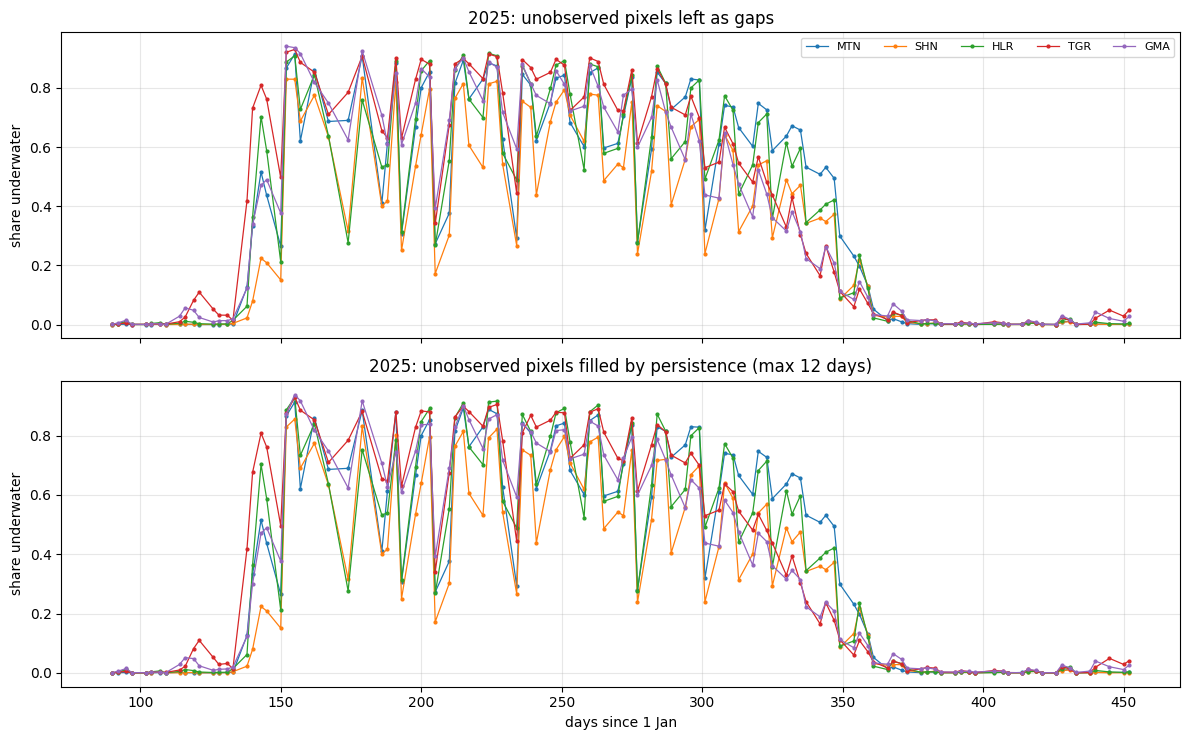

mean absolute step between consecutive dates (lower = smoother)
  unfilled : 0.0993
  filled   : 0.0958
mean raw coverage per date : 0.979
mean effective coverage    : 0.997

timing, unfilled vs filled:
haor_id  onset_hydro_raw  peak_hydro_raw  recession_hydro_raw  max_fraction_raw  onset_hydro_filled  peak_hydro_filled  recession_hydro_filled  max_fraction_filled
    MTN            143.0           155.0                347.0             0.915               143.0              155.0                   347.0                0.914
    SHN            152.0           179.0                335.0             0.835               152.0              155.0                   335.0                0.856
    HLR            143.0           224.0                335.0             0.917               143.0              155.0                   335.0                0.929
    TGR            140.0           155.0                323.0             0.930               140.0              155.0                   323.

In [8]:
# %%
# ============ DIAGNOSTIC: does persistence filling remove the wobble? ============
# Runs one year both ways and compares. This is the before/after evidence the
# supervisor asked for, and the check on whether filling actually helped.
YR  = 2025 if 2025 in results else sorted(results)[-1]
raw = analyze_year(YR, PERM_MASK, fill=False)
fil = results[YR]

fig, ax = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
for hid in HAOR_IDS:
    ax[0].plot(raw["days"], raw["curves"][hid], marker="o", ms=2, lw=.9, label=hid)
    ax[1].plot(fil["days"], fil["curves"][hid], marker="o", ms=2, lw=.9, label=hid)
ax[0].set_title(f"{YR}: unobserved pixels left as gaps"); ax[0].legend(ncol=5, fontsize=8)
ax[1].set_title(f"{YR}: unobserved pixels filled by persistence (max {MAX_GAP_DAYS:.0f} days)")
for a_ in ax:
    a_.grid(alpha=.3); a_.set_ylabel("share underwater")
ax[1].set_xlabel("days since 1 Jan")
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, f"fill_comparison_{YR}.png"), dpi=150)
plt.show()

def wobble(c):
    return float(np.nanmean([np.nanmean(np.abs(np.diff(c[h]))) for h in HAOR_IDS]))
print("mean absolute step between consecutive dates (lower = smoother)")
print(f"  unfilled : {wobble(raw['curves']):.4f}")
print(f"  filled   : {wobble(fil['curves']):.4f}")
print(f"mean raw coverage per date : {raw['obs_raw'].mean():.3f}")
print(f"mean effective coverage    : {fil['obs_eff'].mean():.3f}")
print("\ntiming, unfilled vs filled:")
print(raw["timing"].merge(fil["timing"], on="haor_id",
                          suffixes=("_raw", "_filled")).to_string(index=False))


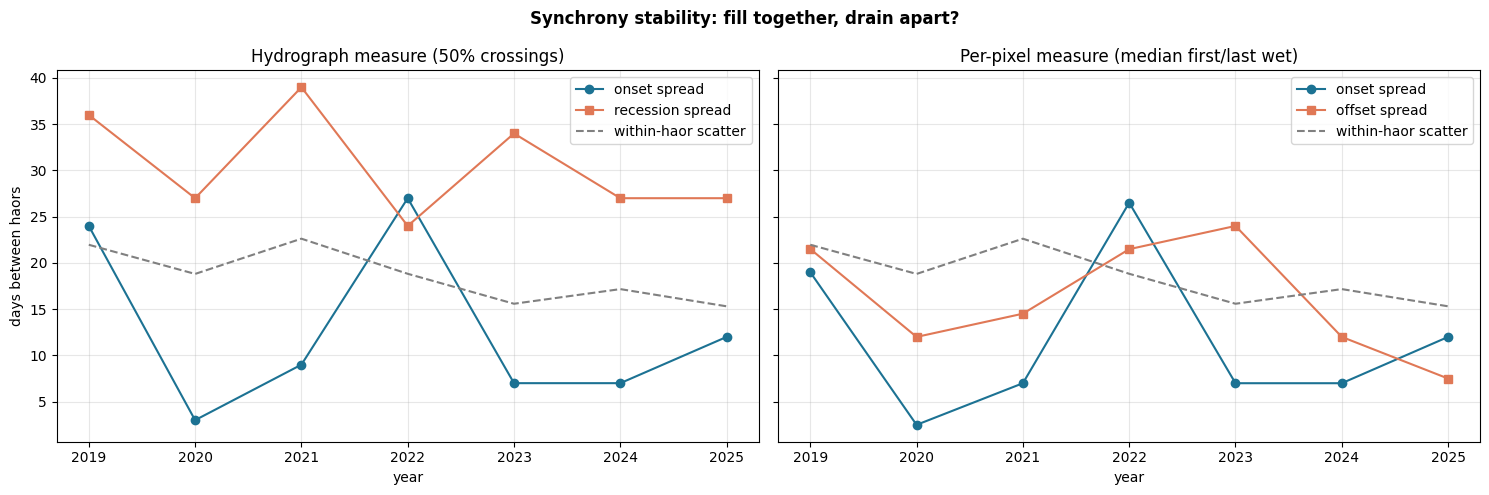

In [9]:
# %%
# ================= CROSS-YEAR FIG 1: synchrony stability =================
# v3: adds onset_between_spread so onset and offset are on the SAME ruler
# (both per-pixel medians), alongside the hydrograph-based spreads.
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax[0].plot(summary_df["year"], summary_df["onset_spread"], "o-", color="#1C7293", label="onset spread")
ax[0].plot(summary_df["year"], summary_df["recession_spread"], "s-", color="#E07856", label="recession spread")
ax[0].plot(summary_df["year"], summary_df["onset_within_std"], "--", color="grey", label="within-haor scatter")
ax[0].set_title("Hydrograph measure (50% crossings)")
ax[0].set_xlabel("year"); ax[0].set_ylabel("days between haors"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(summary_df["year"], summary_df["onset_between_spread"], "o-", color="#1C7293", label="onset spread")
ax[1].plot(summary_df["year"], summary_df["offset_between_spread"], "s-", color="#E07856", label="offset spread")
ax[1].plot(summary_df["year"], summary_df["onset_within_std"], "--", color="grey", label="within-haor scatter")
ax[1].set_title("Per-pixel measure (median first/last wet)")
ax[1].set_xlabel("year"); ax[1].legend(); ax[1].grid(alpha=.3)

fig.suptitle("Synchrony stability: fill together, drain apart?", fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "multiyear_synchrony.png"), dpi=150); plt.show()


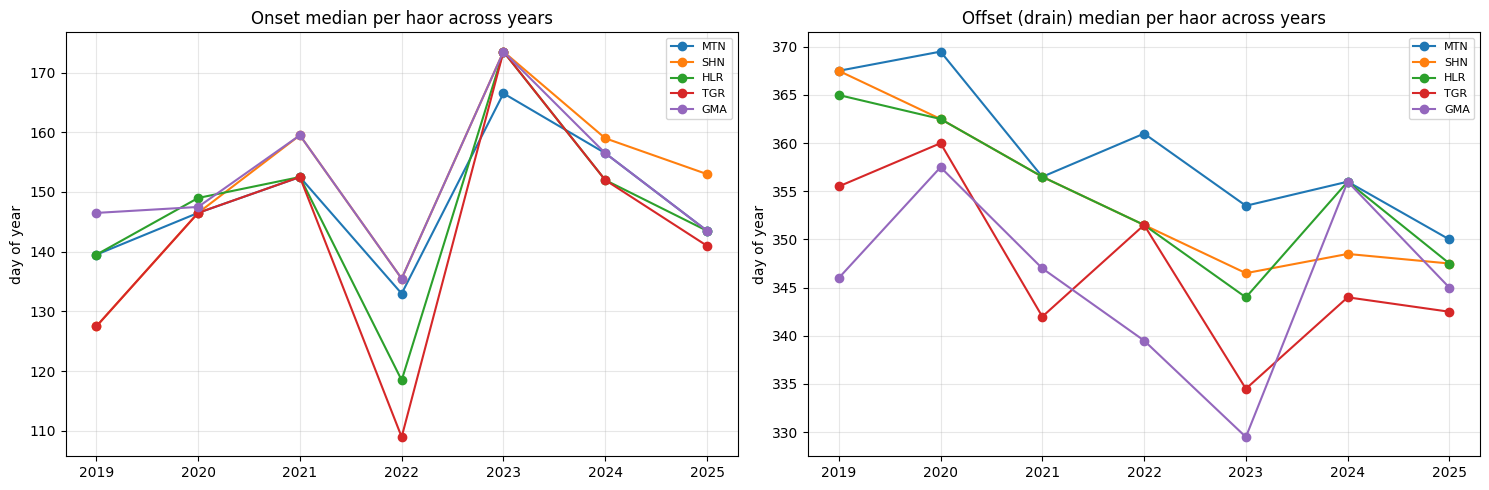

Drain order each year (earliest -> latest):
  2019: GMA < TGR < HLR < SHN < MTN
  2020: GMA < TGR < HLR < SHN < MTN
  2021: TGR < GMA < SHN < MTN < HLR
  2022: GMA < SHN < TGR < HLR < MTN
  2023: GMA < TGR < HLR < SHN < MTN
  2024: TGR < SHN < MTN < HLR < GMA
  2025: TGR < GMA < HLR < SHN < MTN


In [10]:
# %%
# ================= CROSS-YEAR FIG 2: per-haor timing + drain order =================
onset_M = pd.DataFrame({y: results[y]["onset_df"].set_index("haor_id")["onset_median"] for y in results})
offset_M = pd.DataFrame({y: results[y]["offset_df"].set_index("haor_id")["offset_median"] for y in results})

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for hid in onset_M.index: ax[0].plot(onset_M.columns, onset_M.loc[hid], "o-", label=hid)
ax[0].set_title("Onset median per haor across years"); ax[0].set_ylabel("day of year"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
for hid in offset_M.index: ax[1].plot(offset_M.columns, offset_M.loc[hid], "o-", label=hid)
ax[1].set_title("Offset (drain) median per haor across years"); ax[1].set_ylabel("day of year"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "multiyear_perhaor_timing.png"), dpi=150); plt.show()

print("Drain order each year (earliest -> latest):")
drain_orders = {}
for y in results:
    od = results[y]["offset_df"].sort_values("offset_median")["haor_id"].tolist()
    drain_orders[y] = od
    print(f"  {y}: {' < '.join(od)}")


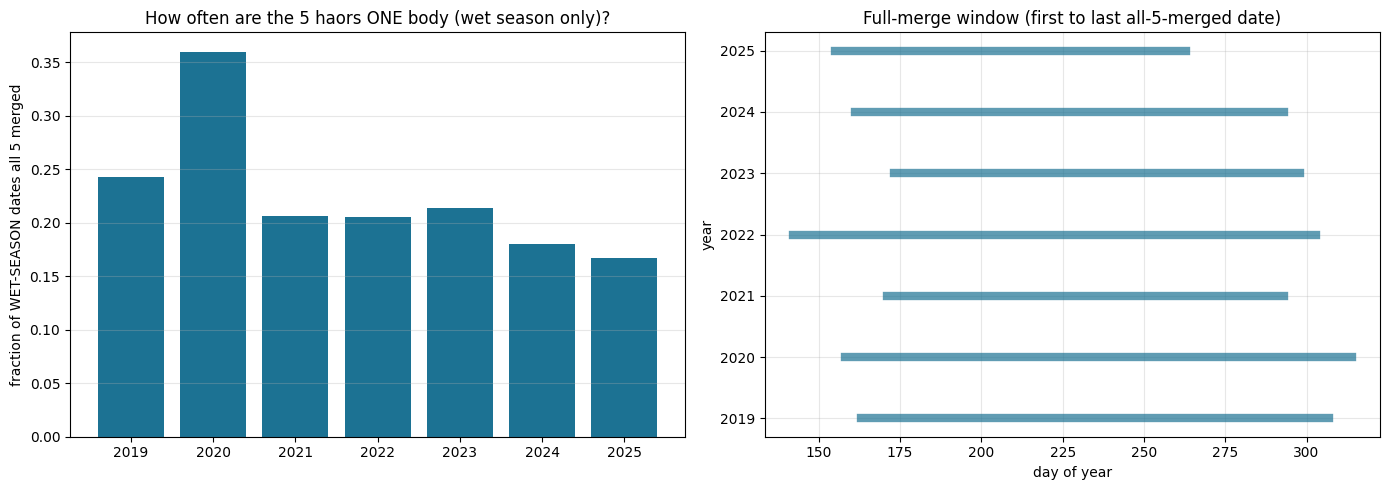

In [11]:
# %%
# ================= CROSS-YEAR FIG 3 (v2): WET-SEASON merge metrics =================
# v1 divided merged dates by ALL observed dates including the dry season, which
# diluted the fraction. v2 divides by wet-season dates only, and also shows the
# merge WINDOW (first to last full-merge day) per year.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(summary_df["year"].astype(str), summary_df["ws_merge_frac"], color="#1C7293")
ax[0].set_ylabel("fraction of WET-SEASON dates all 5 merged")
ax[0].set_title("How often are the 5 haors ONE body (wet season only)?")
ax[0].grid(alpha=.3, axis="y")
for _, r in summary_df.iterrows():
    ax[1].plot([r["merge_first"], r["merge_last"]], [r["year"]] * 2, "-", lw=6, color="#1C7293", alpha=.7)
ax[1].set_xlabel("day of year"); ax[1].set_ylabel("year")
ax[1].set_title("Full-merge window (first to last all-5-merged date)")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "multiyear_merge_v2.png"), dpi=150); plt.show()


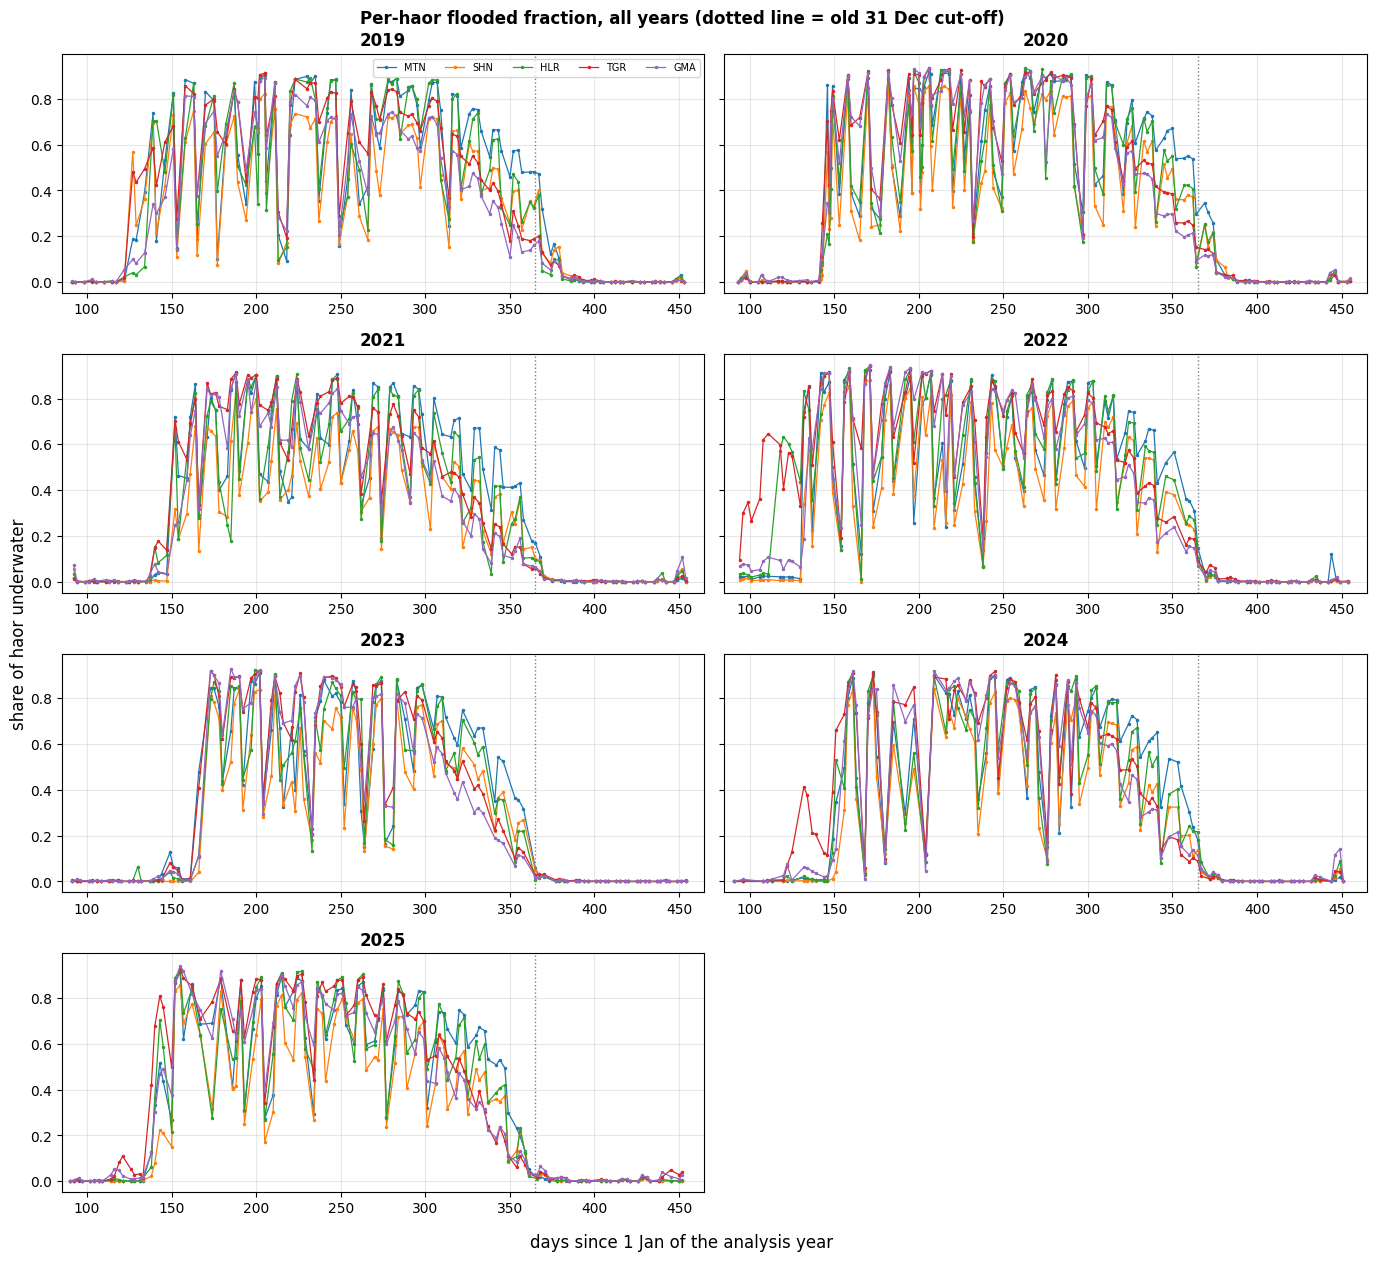

In [12]:
# %%
# ================= GRID 1: hydrographs, one panel per year =================
ny = len(results); ncol = 2; nrow = int(np.ceil(ny / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 3.2 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()
for k, y in enumerate(sorted(results)):
    r = results[y]; d = r["days"]; o = np.argsort(d)
    for hid, fr in r["curves"].items():
        axes[k].plot(d[o], fr[o], marker="o", ms=1.5, lw=.9, label=hid)
    axes[k].set_title(str(y), fontweight="bold"); axes[k].grid(alpha=.3)
    axes[k].set_xlim(XMIN, XMAX)                      # v3: extends past day 365
    axes[k].axvline(365, color="grey", ls=":", lw=1)  # marks the old cut-off
    if k == 0:
        axes[k].legend(fontsize=7, ncol=5)
for k in range(len(results), len(axes)):
    axes[k].axis("off")
fig.suptitle("Per-haor flooded fraction, all years (dotted line = old 31 Dec cut-off)", fontweight="bold")
fig.supxlabel("days since 1 Jan of the analysis year"); fig.supylabel("share of haor underwater")
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "grid_hydrographs.png"), dpi=150); plt.show()


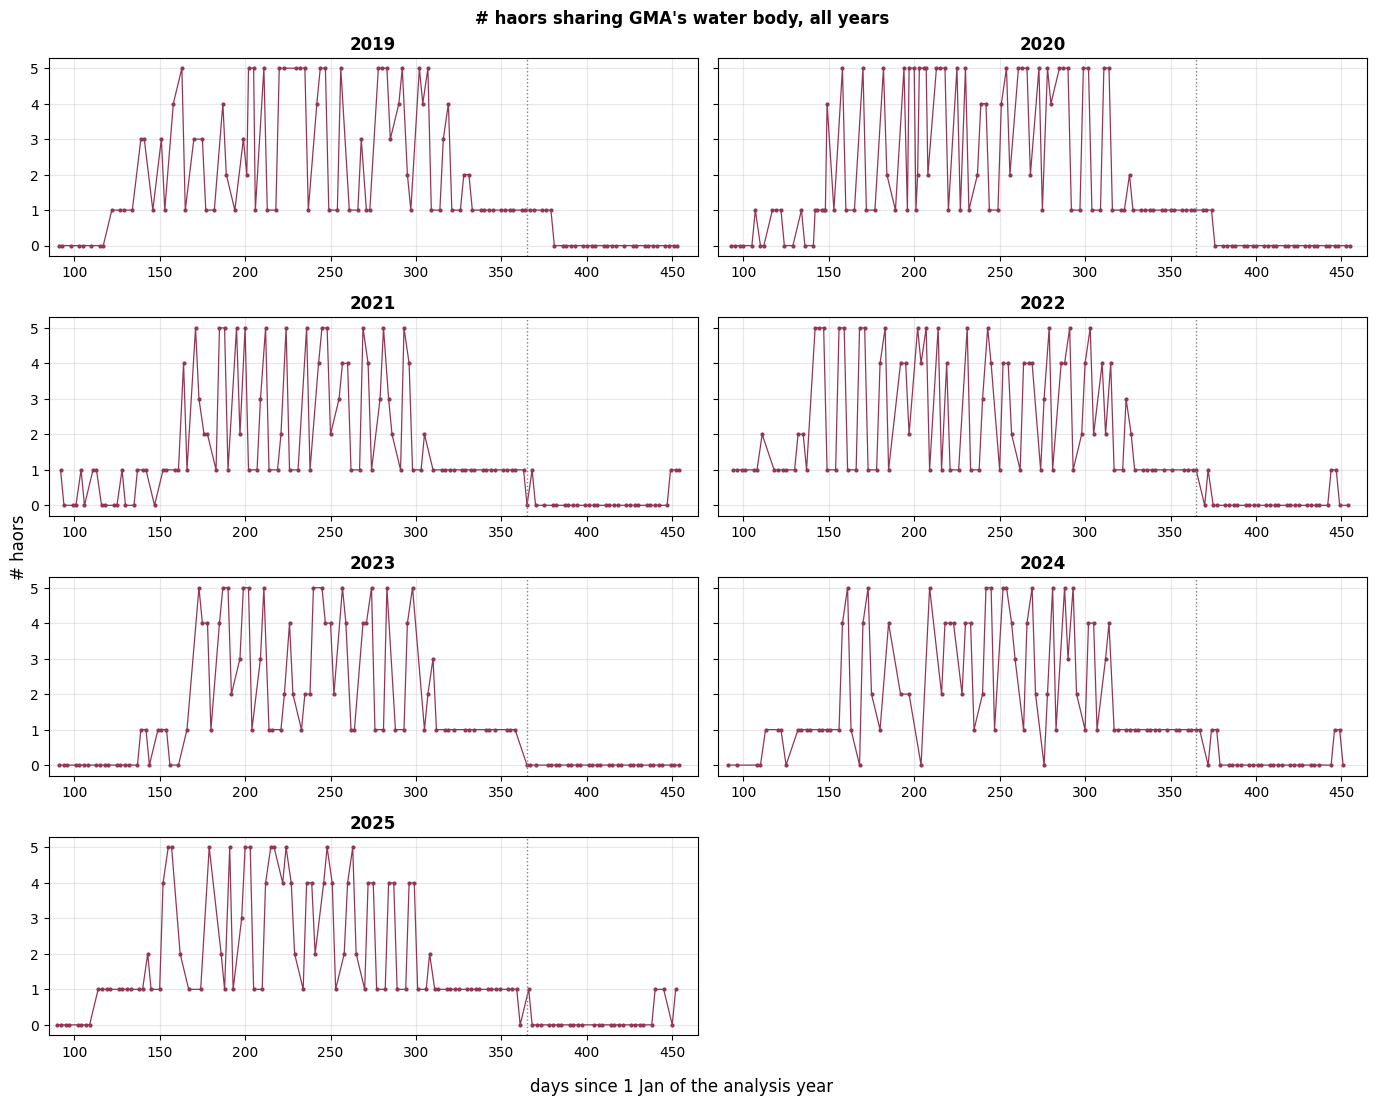

In [13]:
# %%
# ================= GRID 2: connectivity (# haors sharing GMA), per year =================
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.8 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()
central = CENTRAL_HAOR if CENTRAL_HAOR in HAOR_IDS else HAOR_IDS[0]
for k, y in enumerate(sorted(results)):
    r  = results[y]
    mv = r["matrix_df"][r["matrix_df"][central] >= 0]
    linked = [int(sum(row[h] == row[central] and row[central] > 0 for h in HAOR_IDS))
              for _, row in mv.iterrows()]
    axes[k].plot(mv["doy"], linked, "o-", ms=2, lw=.9, color="#933556")
    axes[k].set_title(str(y), fontweight="bold"); axes[k].set_ylim(-0.3, 5.3); axes[k].grid(alpha=.3)
    axes[k].set_xlim(XMIN, XMAX)
    axes[k].axvline(365, color="grey", ls=":", lw=1)
for k in range(len(results), len(axes)):
    axes[k].axis("off")
fig.suptitle(f"# haors sharing {central}'s water body, all years", fontweight="bold")
fig.supxlabel("days since 1 Jan of the analysis year"); fig.supylabel("# haors")
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "grid_connectivity.png"), dpi=150); plt.show()


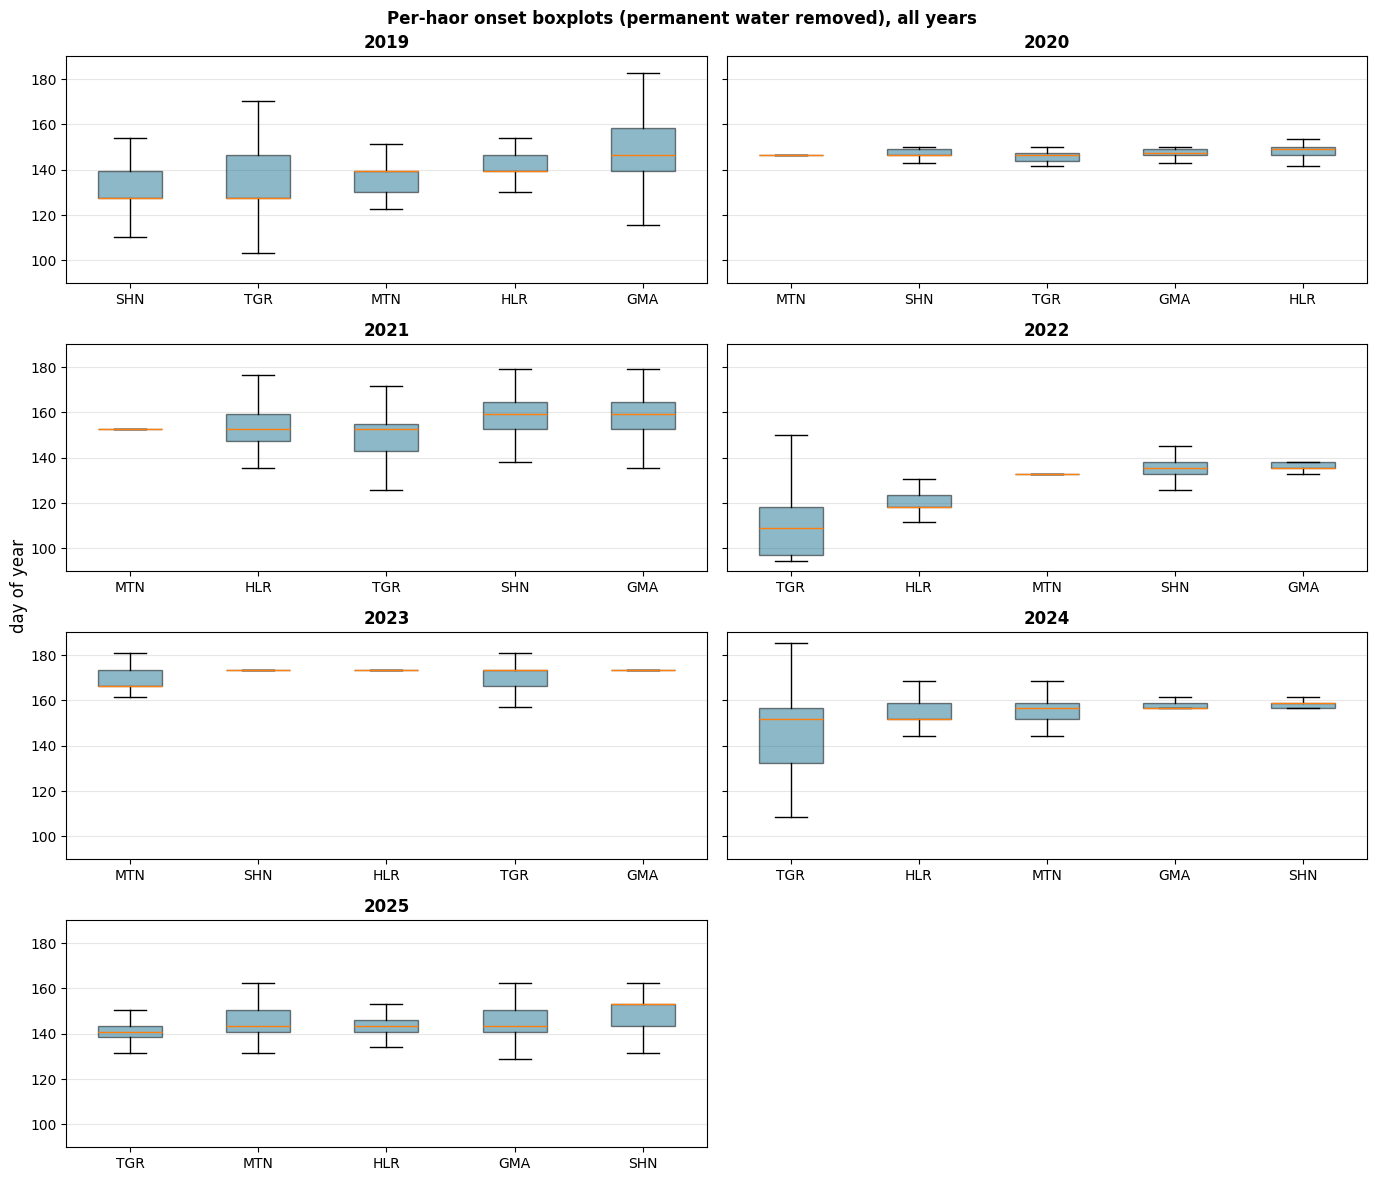

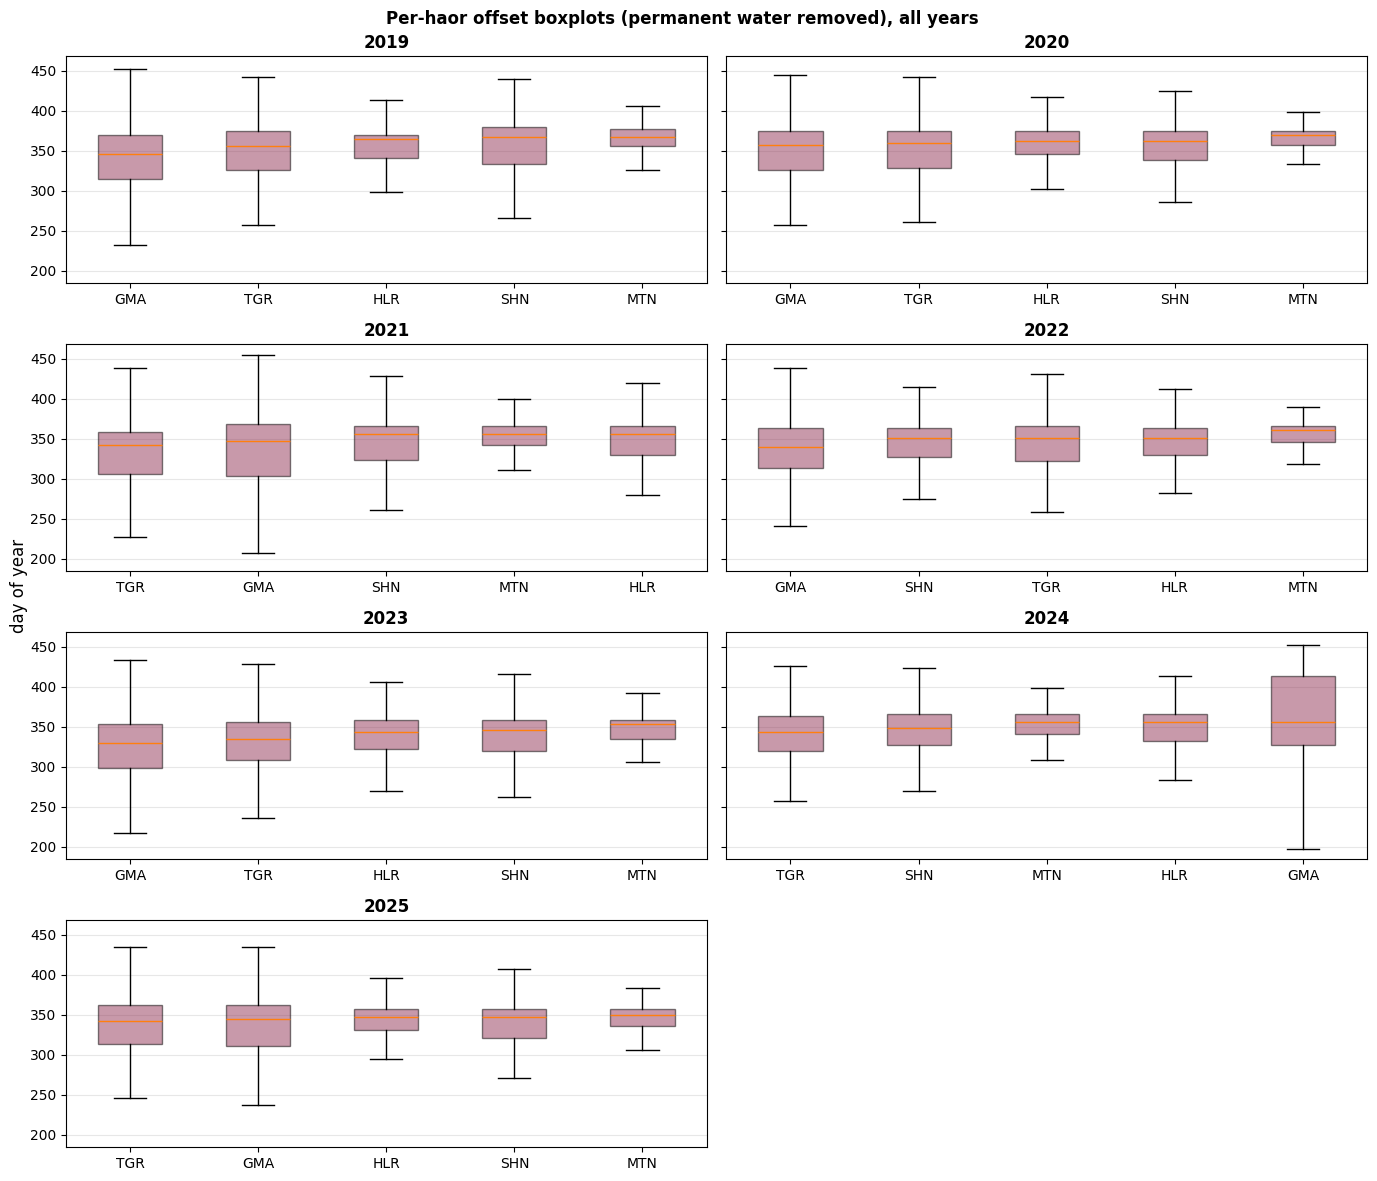

In [14]:
# %%
# ================= NEW GRIDS 3+4: onset and offset boxplots per year =================
for tag, dist_key, color in [("onset", "onset_dist", "#1C7293"), ("offset", "offset_dist", "#933556")]:
    fig, axes = plt.subplots(nrow, ncol, figsize=(14, 3.0 * nrow), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for k, y in enumerate(sorted(results)):
        r = results[y]
        med = r[f"{tag}_df"].sort_values(f"{tag}_median")
        order = med["haor_id"].tolist()
        bp = axes[k].boxplot([r[dist_key][h] for h in order], tick_labels=order,
                             showfliers=False, patch_artist=True)
        for p in bp["boxes"]: p.set_facecolor(color); p.set_alpha(.5)
        axes[k].set_title(str(y), fontweight="bold"); axes[k].grid(alpha=.3, axis="y")
    for k in range(len(results), len(axes)): axes[k].axis("off")
    fig.suptitle(f"Per-haor {tag} boxplots (permanent water removed), all years", fontweight="bold")
    fig.supylabel("day of year")
    plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, f"grid_{tag}_box.png"), dpi=150); plt.show()


In [15]:
# %%
# ================= KENDALL'S W: is the drain order non-random? =================
# Ranks the 5 haors by offset median in each year and tests agreement of the
# rankings across years. W=1 means identical order every year; the chi-square
# approximation gives a p-value. This formalizes "GMA first, MTN last, 7/7".
rank_M = offset_M.rank(axis=0)          # rank within each year (1 = earliest drain)
m = rank_M.shape[1]                      # number of years (judges)
n = rank_M.shape[0]                      # number of haors (items)
R = rank_M.sum(axis=1)                   # total rank per haor
S = float(((R - R.mean()) ** 2).sum())
W = 12 * S / (m ** 2 * (n ** 3 - n))
chi2 = m * (n - 1) * W
p = float(chi2_dist.sf(chi2, df=n - 1))
print("mean drain rank per haor (1 = drains first):")
print((R / m).sort_values().to_string())
print(f"\nKendall's W = {W:.3f}  (1 = perfectly consistent order)")
print(f"chi2 = {chi2:.1f}, df = {n-1}, p = {p:.2e}")
print("-> small p: the drain order is NOT random across years; it is structural.")


mean drain rank per haor (1 = drains first):
haor_id
TGR    1.714286
GMA    1.785714
HLR    3.500000
SHN    3.500000
MTN    4.500000

Kendall's W = 0.588  (1 = perfectly consistent order)
chi2 = 16.5, df = 4, p = 2.46e-03
-> small p: the drain order is NOT random across years; it is structural.


In [16]:
# %%
# ================= MECHANISM v2: OUTWARD rim elevation vs drain order =================
# Why v1 failed: the rim corridor buffered BOTH ways, so it swallowed haor-floor
# and open-water pixels, and p5 of 20k pixels found the floor (0 m) for every
# haor -> the metric saturated and rho was exactly 0. Fixes:
#   1. outward-only ring: buffer(150).difference(polygon) — floor excluded
#   2. permanent water masked with JRC occurrence (>75%)
#   3. exact-zero / nodata pixels dropped (FABDEM water artifacts pin at 0)
UTM = "EPSG:32646"
with rasterio.open(FABDEM_TIF) as fsrc, rasterio.open(JRC_TIF) as jsrc:
    h_utm = haors.to_crs(UTM)
    rim_rows = []
    for _, h in h_utm.iterrows():
        ring = h.geometry.buffer(150).difference(h.geometry)     # OUTWARD ring only
        ring_r = gpd.GeoSeries([ring], crs=UTM).to_crs(fsrc.crs).iloc[0]
        try:
            dat, tr = rmask(fsrc, [mapping(ring_r)], crop=True, filled=False)
        except ValueError:
            print(f"  {h.haor_id}: ring outside FABDEM"); continue
        elev = np.ma.filled(dat[0], np.nan).astype("float32")
        # JRC occurrence onto the same grid -> mask permanent water
        jrc_g = np.full(elev.shape, np.nan, "float32")
        reproject(rasterio.band(jsrc, 1), jrc_g, src_transform=jsrc.transform,
                  src_crs=jsrc.crs, dst_transform=tr, dst_crs=fsrc.crs,
                  resampling=Resampling.bilinear)
        keep = np.isfinite(elev) & (np.abs(elev) > 0.05) & ~(np.isfinite(jrc_g) & (jrc_g > 75))
        vals = elev[keep]
        if vals.size < 100:
            print(f"  {h.haor_id}: too few clean rim pixels ({vals.size})"); continue
        rim_rows.append(dict(haor_id=h.haor_id, n_px=int(vals.size),
            rim_p2=float(np.percentile(vals, 2)), rim_p5=float(np.percentile(vals, 5)),
            rim_p10=float(np.percentile(vals, 10)), rim_median=float(np.median(vals))))
rim_df = pd.DataFrame(rim_rows).set_index("haor_id")
rim_df = rim_df.join((offset_M.rank(axis=0).mean(axis=1)).rename("mean_drain_rank"))
rim_df.to_csv(os.path.join(ANALYSIS_ROOT, "rim_elevation_vs_drain_v2.csv"))
print(rim_df.sort_values("mean_drain_rank").to_string())
rho, pval = spearmanr(rim_df["mean_drain_rank"], rim_df["rim_p5"])
print(f"\nSpearman (drain rank vs OUTWARD rim p5): rho={rho:.2f}, p={pval:.3f}")
print("Caveat: FABDEM vertical error (~1 m+) vs total relief (~0-6 m) is large in")
print("this basin; if values still cluster, the DEM cannot resolve the mechanism")
print("and the SWOT levels become the better mechanism probe.")

         n_px  rim_p2  rim_p5  rim_p10  rim_median  mean_drain_rank
haor_id                                                            
TGR      7566     1.5     2.5     2.84       4.965         1.714286
GMA      8601     0.5     1.0     2.00       4.230         1.785714
HLR      6122     0.5     0.5     1.00       4.650         3.500000
SHN      7878     0.5     0.5     1.00       4.500         3.500000
MTN      6491     1.5     2.5     2.74       4.390         4.500000

Spearman (drain rank vs OUTWARD rim p5): rho=-0.16, p=0.794
Caveat: FABDEM vertical error (~1 m+) vs total relief (~0-6 m) is large in
this basin; if values still cluster, the DEM cannot resolve the mechanism
and the SWOT levels become the better mechanism probe.


In [17]:
# %%
# ================= MECHANISM 2: inter-haor SILL elevations =================
# For each ADJACENT pair, the boundary corridor's low elevation is the sill the
# water must top for the pair to merge. Lower sill = pair should merge earlier
# and stay merged longer. Output: pairwise sill matrix to compare against the
# connection matrix later.
pairs = []
with rasterio.open(FABDEM_TIF) as fsrc:
    for i in range(len(h_utm)):
        for j in range(i + 1, len(h_utm)):
            a, b = h_utm.iloc[i], h_utm.iloc[j]
            corridor = a.geometry.buffer(300).intersection(b.geometry.buffer(300))
            if corridor.is_empty: continue
            cor_r = gpd.GeoSeries([corridor], crs=UTM).to_crs(fsrc.crs).iloc[0]
            try:
                dat, _ = rmask(fsrc, [mapping(cor_r)], crop=True, filled=False)
            except ValueError:
                continue
            vals = np.ma.filled(dat[0], np.nan).astype("float32")
            vals = vals[np.isfinite(vals)]
            if vals.size < 10: continue
            pairs.append(dict(pair=f"{a.haor_id}-{b.haor_id}",
                sill_p5=float(np.percentile(vals, 5)),
                sill_median=float(np.median(vals)), n_px=vals.size))
sill_df = pd.DataFrame(pairs).sort_values("sill_p5")
sill_df.to_csv(os.path.join(ANALYSIS_ROOT, "interhaor_sills.csv"), index=False)
print("Inter-haor boundary sill elevations (lower = merges first):")
print(sill_df.to_string(index=False))
print("\nRead: pairs with the LOWEST sills should be the FIRST to appear merged in")
print("the connection matrix each rising season, and the LAST to separate.")


Inter-haor boundary sill elevations (lower = merges first):
   pair  sill_p5  sill_median  n_px
MTN-TGR      0.0         2.92  7449
MTN-GMA      0.0         4.04  1520
HLR-GMA      0.0         3.16  7232
SHN-HLR      0.5         3.83  6272
TGR-GMA      0.5         5.00  7619
SHN-GMA      0.5         4.05  4140
MTN-SHN      3.0         5.17  6958

Read: pairs with the LOWEST sills should be the FIRST to appear merged in
the connection matrix each rising season, and the LAST to separate.


In [18]:
# %%
# ================= SWOT: load the precomputed per-haor water levels =================
# The heavy extraction lives in swot_extract_wse.py and does NOT need re-running
# for v3: the water levels are independent of the flood-mapping changes. Only
# the merged/separate LABELS change, because they come from the connection
# matrices, so the pairing cell below must be re-run.
assert os.path.exists(SWOT_CSV), f"run swot_extract_wse.py first: {SWOT_CSV}"
swot_df = pd.read_csv(SWOT_CSV, parse_dates=["dt"])
swot_df["res_rank"] = (swot_df["res"] != "100m").astype(int)
swot_df = (swot_df.sort_values(["dt", "haor_id", "res_rank", "n"],
                               ascending=[True, True, True, False])
                  .drop_duplicates(subset=["dt", "haor_id"], keep="first"))
print(f"{len(swot_df)} per-haor WSE rows | dates per year:",
      swot_df.groupby("year")["doy"].nunique().to_dict())


960 per-haor WSE rows | dates per year: {2023: 25, 2024: 64, 2025: 67, 2026: 3}


          count   mean    std    min    25%    50%    75%    max
state                                                           
merged    210.0  0.143  0.272  0.002  0.064  0.105  0.150  2.374
separate  658.0  0.314  0.423  0.000  0.086  0.151  0.297  2.468


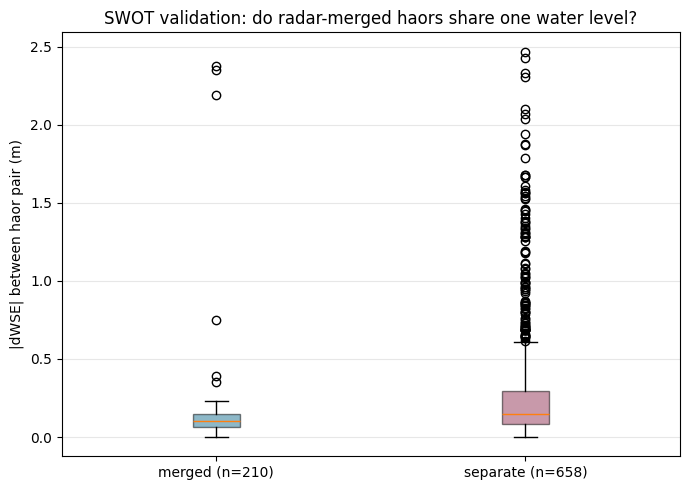

In [19]:
# %%
# ================= SWOT VALIDATION: do merged haors share one water level? =================
# v3 fix: the connectivity matrix now uses "days since 1 Jan of the ANALYSIS
# year", so a SWOT pass in Jan-Mar belongs to the PREVIOUS analysis year and its
# day index must be shifted by the length of that year. Without this remap the
# early-year SWOT passes would never match.
TOL_DAYS = 3

def year_len(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

daily = (swot_df.groupby(["year", "doy", "haor_id"])["wse_median"].median().reset_index())

pair_rows = []
for (yr, doy), grp in daily.groupby(["year", "doy"]):
    # a Jan-Mar pass belongs to the previous analysis year, shifted past day 365
    cands = [(yr, float(doy))]
    if doy <= 95:
        cands.append((yr - 1, float(doy) + year_len(yr - 1)))
    for ayear, dayidx in cands:
        if ayear not in results:
            continue
        mat = results[ayear]["matrix_df"]
        mat = mat[mat[HAOR_IDS[0]] >= 0]
        if not len(mat):
            continue
        k = (mat["doy"] - dayidx).abs().idxmin()
        if abs(mat.loc[k, "doy"] - dayidx) > TOL_DAYS:
            continue
        comp = mat.loc[k, HAOR_IDS]
        g = grp.set_index("haor_id")["wse_median"]
        hids = [h for h in HAOR_IDS if h in g.index]
        for i in range(len(hids)):
            for j in range(i + 1, len(hids)):
                a, b = hids[i], hids[j]
                if comp[a] <= 0 or comp[b] <= 0:
                    continue
                pair_rows.append(dict(analysis_year=ayear, doy=dayidx, pair=f"{a}-{b}",
                    dwse=float(abs(g[a] - g[b])),
                    state="merged" if comp[a] == comp[b] else "separate"))
        break   # matched, do not double count

pairs_df = pd.DataFrame(pair_rows)
if len(pairs_df):
    pairs_df.to_csv(os.path.join(ANALYSIS_ROOT, "swot_pair_validation.csv"), index=False)
    print(pairs_df.groupby("state")["dwse"].describe().round(3).to_string())
    fig, ax = plt.subplots(figsize=(7, 5))
    data = [pairs_df.loc[pairs_df.state == s, "dwse"].values for s in ["merged", "separate"]]
    bp = ax.boxplot(data, tick_labels=[f"merged (n={len(data[0])})", f"separate (n={len(data[1])})"],
                    showfliers=True, patch_artist=True)
    for p_, c in zip(bp["boxes"], ["#1C7293", "#933556"]):
        p_.set_facecolor(c); p_.set_alpha(.5)
    ax.set_ylabel("|dWSE| between haor pair (m)")
    ax.set_title("SWOT validation: do radar-merged haors share one water level?")
    ax.grid(alpha=.3, axis="y")
    plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "swot_validation.png"), dpi=150); plt.show()
else:
    print("no SWOT date matched a connectivity date within +/- TOL_DAYS; widen TOL_DAYS to 5.")


In [20]:
# %%
# ====== ROBUSTNESS: drain order from hydrograph recession vs per-pixel offset ======
# The per-pixel offset uses max() over dates, so ONE spurious detection in the
# Feb-Mar tail sets that pixel's last-wet to ~day 450. The 2024 GMA offset box
# spanning 200-455 days is exactly that failure. The hydrograph recession uses
# the whole-basin curve and cannot be moved by a few pixels, so it is the more
# robust ranking variable. This computes Kendall's W both ways.
from scipy.stats import chi2 as _c2

def kendall_W(M):
    rank_M = M.rank(axis=0)
    m, n = rank_M.shape[1], rank_M.shape[0]
    R = rank_M.sum(axis=1); S = float(((R - R.mean()) ** 2).sum())
    W = 12 * S / (m ** 2 * (n ** 3 - n)); chi2 = m * (n - 1) * W
    return W, chi2, float(_c2.sf(chi2, df=n - 1)), (R / m).sort_values()

offset_M = pd.DataFrame({y: results[y]["offset_df"].set_index("haor_id")["offset_median"]
                         for y in results})
rec_M    = pd.DataFrame({y: results[y]["timing"].set_index("haor_id")["recession_hydro"]
                         for y in results})

for name, M in [("per-pixel offset median (current)", offset_M),
                ("hydrograph recession (robust)", rec_M)]:
    W, chi2, p, meanrank = kendall_W(M)
    print(f"\n=== {name} ===")
    print(meanrank.to_string())
    print(f"Kendall's W = {W:.3f}   chi2 = {chi2:.2f}   p = {p:.2e}")
    for y in M.columns:
        print(f"   {y}: {' < '.join(M[y].sort_values().index)}")


=== per-pixel offset median (current) ===
haor_id
TGR    1.714286
GMA    1.785714
HLR    3.500000
SHN    3.500000
MTN    4.500000
Kendall's W = 0.588   chi2 = 16.46   p = 2.46e-03
   2019: GMA < TGR < HLR < SHN < MTN
   2020: GMA < TGR < HLR < SHN < MTN
   2021: TGR < GMA < SHN < MTN < HLR
   2022: GMA < SHN < TGR < HLR < MTN
   2023: GMA < TGR < HLR < SHN < MTN
   2024: TGR < SHN < MTN < HLR < GMA
   2025: TGR < GMA < HLR < SHN < MTN

=== hydrograph recession (robust) ===
haor_id
GMA    1.142857
TGR    1.928571
SHN    3.285714
HLR    3.642857
MTN    5.000000
Kendall's W = 0.909   chi2 = 25.46   p = 4.07e-05
   2019: TGR < GMA < SHN < HLR < MTN
   2020: GMA < TGR < HLR < SHN < MTN
   2021: GMA < TGR < HLR < SHN < MTN
   2022: TGR < GMA < HLR < SHN < MTN
   2023: GMA < TGR < HLR < SHN < MTN
   2024: GMA < SHN < TGR < HLR < MTN
   2025: GMA < TGR < HLR < SHN < MTN


In [21]:
# %%
# ====== DIAGNOSTIC: spurious detections in the Feb-Mar tail ======
for y in sorted(results):
    r = results[y]; d = r["days"]; late = d > 400
    if late.sum():
        fr = {h: float(np.nanmean(r["curves"][h][late])) for h in HAOR_IDS}
        print(f"{y}: {int(late.sum())} dates after day 400 | mean flooded fraction " +
              ", ".join(f"{h}={v:.3f}" for h, v in fr.items()))

2019: 17 dates after day 400 | mean flooded fraction MTN=0.002, SHN=0.002, HLR=0.003, TGR=0.002, GMA=0.002
2020: 18 dates after day 400 | mean flooded fraction MTN=0.003, SHN=0.005, HLR=0.004, TGR=0.005, GMA=0.007
2021: 19 dates after day 400 | mean flooded fraction MTN=0.002, SHN=0.006, HLR=0.007, TGR=0.005, GMA=0.011
2022: 18 dates after day 400 | mean flooded fraction MTN=0.008, SHN=0.001, HLR=0.003, TGR=0.003, GMA=0.003
2023: 19 dates after day 400 | mean flooded fraction MTN=0.001, SHN=0.000, HLR=0.001, TGR=0.001, GMA=0.001
2024: 17 dates after day 400 | mean flooded fraction MTN=0.002, SHN=0.005, HLR=0.008, TGR=0.007, GMA=0.019
2025: 16 dates after day 400 | mean flooded fraction MTN=0.003, SHN=0.002, HLR=0.004, TGR=0.013, GMA=0.011
